# Reliability Assessment Framework for Small Tabular Binary Classification Datasets

This notebook contains the simulation workflow and the analyses reported in the manuscript:

**A Framework for Reliability Assessment of Binary Classification Models in Small Tabular Datasets**

The workflow evaluates Logit, Firth logistic regression, Elastic Net, and CART using repeated bootstrap resampling. Reliability is described using five dimensions:

1. Mean AUC
2. Standard deviation of AUC
3. Mean Brier Score
4. Standard deviation of Brier Score
5. Prediction variability

Pareto dominance is used to identify non dominated alternatives. Convergence and the number of valid repetitions are reported separately.

The repository includes the final simulation output so that the reported summaries can be reproduced without rerunning the full simulation.

## 1. Setup

The full simulation requires the packages listed in `requirements.txt`. The final CSV can be analyzed without rerunning the complete simulation.

Set `RUN_FULL_SIMULATION = True` only if you want to regenerate all 60 scenarios. This is computationally intensive because each scenario contains 50 independent datasets and each dataset is evaluated with 100 bootstrap repetitions.

In [1]:
from pathlib import Path
from itertools import product
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from scipy.optimize import brentq

from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import statsmodels.api as sm

try:
    from firthmodels import FirthLogisticRegression
except ImportError:
    FirthLogisticRegression = None

RUN_FULL_SIMULATION = False
RESULTS_FILE = Path("results_simulation_complete_v3.csv")
SEED = 42


## 2. Simulation design

The design combines five sample sizes, three numbers of predictors, two expected prevalences, and two correlation levels, producing 60 scenarios. Each scenario contains 50 independent datasets.

In [2]:
SAMPLE_SIZES = [30, 50, 75, 100, 150]
N_PREDICTORS = [5, 10, 15]
PREVALENCES = [0.50, 0.20]
CORRELATIONS = [0.0, 0.5]

scenarios = []
scenario_id = 1

for n, p, prevalence, rho in product(
    SAMPLE_SIZES,
    N_PREDICTORS,
    PREVALENCES,
    CORRELATIONS,
):
    scenarios.append({
        "Escenario": scenario_id,
        "n": n,
        "p": p,
        "Prevalencia": prevalence,
        "Correlacion": rho,
    })
    scenario_id += 1

scenario_table = pd.DataFrame(scenarios)
print("Number of scenarios:", len(scenario_table))
scenario_table.head()


Number of scenarios: 60


,Escenario,n,p,Prevalencia,Correlacion
0,1,30,5,0.5,0.0
1,2,30,5,0.5,0.5
2,3,30,5,0.2,0.0
3,4,30,5,0.2,0.5
4,5,30,10,0.5,0.0


## 3. Simulated data generation

Predictors follow a multivariate normal distribution with equicorrelation. Three predictors have nonzero effects equivalent to odds ratios of 2.0, 1.5, and 0.67. The remaining predictors have null effects. The intercept is adjusted to obtain the expected prevalence for each scenario.

In [3]:
def generate_dataset(
    n=50,
    p=5,
    prevalence=0.50,
    rho=0.0,
    seed=42,
):
    rng = np.random.default_rng(seed)

    covariance = np.full((p, p), rho)
    np.fill_diagonal(covariance, 1.0)

    X = rng.multivariate_normal(
        mean=np.zeros(p),
        cov=covariance,
        size=n,
    )

    beta = np.zeros(p)
    beta[:3] = np.log([2.0, 1.5, 0.67])

    linear_predictor = X @ beta

    def intercept_equation(intercept):
        return expit(intercept + linear_predictor).mean() - prevalence

    intercept = brentq(intercept_equation, -20, 20)
    probabilities = expit(intercept + linear_predictor)
    y = rng.binomial(1, probabilities)

    columns = [f"X{i + 1}" for i in range(p)]
    data = pd.DataFrame(X, columns=columns)
    data["Y"] = y

    return data, beta, intercept


## 4. Reliability profile and Pareto dominance

Performance metrics are calculated from out of bag observations. Prediction variability is calculated from the probabilities generated for the complete simulated dataset across valid bootstrap fits. A model dominates another model when it is equal or better in all five reliability dimensions and strictly better in at least one.

In [4]:
RELIABILITY_COLUMNS = [
    "AUC_media",
    "AUC_DE",
    "Brier_media",
    "Brier_DE",
    "DE_prediccion",
]

def dominates(a, b):
    if a[RELIABILITY_COLUMNS].isna().any() or b[RELIABILITY_COLUMNS].isna().any():
        return False

    equal_or_better = [
        a["AUC_media"] >= b["AUC_media"],
        a["AUC_DE"] <= b["AUC_DE"],
        a["Brier_media"] <= b["Brier_media"],
        a["Brier_DE"] <= b["Brier_DE"],
        a["DE_prediccion"] <= b["DE_prediccion"],
    ]

    strictly_better = [
        a["AUC_media"] > b["AUC_media"],
        a["AUC_DE"] < b["AUC_DE"],
        a["Brier_media"] < b["Brier_media"],
        a["Brier_DE"] < b["Brier_DE"],
        a["DE_prediccion"] < b["DE_prediccion"],
    ]

    return all(equal_or_better) and any(strictly_better)


def apply_dominance(profile):
    profile = profile.copy()
    dominated_models = set()

    evaluable = profile[profile["Estado"] != "No evaluable"].copy()

    for i in evaluable.index:
        for j in evaluable.index:
            if i == j:
                continue
            if dominates(evaluable.loc[i], evaluable.loc[j]):
                dominated_models.add(evaluable.loc[j, "Modelo"])

    for i in profile.index:
        if profile.loc[i, "Estado"] == "No evaluable":
            continue
        model = profile.loc[i, "Modelo"]
        profile.loc[i, "Estado"] = (
            "Dominado" if model in dominated_models else "No dominado"
        )

    return profile


## 5. Bootstrap evaluation of one simulated dataset

The same bootstrap sample is used for all candidate models within each repetition. Observations not selected in the bootstrap sample are used to calculate AUC and Brier Score. Repetitions without both outcome classes in the training or out of bag samples are skipped.

In [5]:
def evaluate_dataset(
    n,
    p,
    prevalence,
    rho,
    B=100,
    seed=42,
):
    if FirthLogisticRegression is None:
        raise ImportError(
            "The full simulation requires the 'firthmodels' package. "
            "Install the dependencies in requirements.txt before rerunning it."
        )

    model_names = ["Logit", "Firth", "Elastic Net", "CART"]

    data, beta_true, intercept_true = generate_dataset(
        n=n,
        p=p,
        prevalence=prevalence,
        rho=rho,
        seed=seed,
    )

    X = data.drop(columns=["Y"]).copy()
    y = data["Y"].copy()
    observed_prevalence = y.mean()

    if y.nunique() < 2:
        profile = pd.DataFrame({
            "Modelo": model_names,
            "AUC_media": [np.nan] * 4,
            "AUC_DE": [np.nan] * 4,
            "Brier_media": [np.nan] * 4,
            "Brier_DE": [np.nan] * 4,
            "DE_prediccion": [np.nan] * 4,
            "Convergencia_pct": [0.0] * 4,
            "Repeticiones_validas": [0] * 4,
            "Estado": ["No evaluable"] * 4,
        })
        return {
            "perfil": profile,
            "prevalencia_observada": observed_prevalence,
            "beta_real": beta_true,
            "intercepto": intercept_true,
        }

    rng = np.random.default_rng(seed + 1000)

    results = []
    predictions = {name: [] for name in model_names}
    convergence = {name: [] for name in model_names}

    for _ in range(B):
        idx_boot = rng.choice(np.arange(n), size=n, replace=True)
        idx_oob = np.setdiff1d(np.arange(n), np.unique(idx_boot))

        X_boot = X.iloc[idx_boot]
        y_boot = y.iloc[idx_boot]
        X_oob = X.iloc[idx_oob]
        y_oob = y.iloc[idx_oob]

        if (
            y_boot.nunique() < 2
            or len(idx_oob) == 0
            or y_oob.nunique() < 2
        ):
            continue

        # Logit
        try:
            X_boot_logit = sm.add_constant(X_boot, has_constant="add")
            X_oob_logit = sm.add_constant(X_oob, has_constant="add")
            X_total_logit = sm.add_constant(X, has_constant="add")

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fitted = sm.Logit(y_boot, X_boot_logit).fit(
                    disp=False,
                    maxiter=200,
                )

            converged = bool(fitted.mle_retvals["converged"])

            if converged:
                prob_oob = np.asarray(fitted.predict(X_oob_logit))
                prob_total = np.asarray(fitted.predict(X_total_logit))

                results.append({
                    "modelo": "Logit",
                    "AUC": roc_auc_score(y_oob, prob_oob),
                    "Brier": brier_score_loss(y_oob, prob_oob),
                })
                predictions["Logit"].append(prob_total)
                convergence["Logit"].append(True)
            else:
                convergence["Logit"].append(False)
        except Exception:
            convergence["Logit"].append(False)

        # Firth
        try:
            model = FirthLogisticRegression(max_iter=500)

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(X_boot, y_boot)

            if model.converged_:
                prob_oob = model.predict_proba(X_oob)[:, 1]
                prob_total = model.predict_proba(X)[:, 1]

                results.append({
                    "modelo": "Firth",
                    "AUC": roc_auc_score(y_oob, prob_oob),
                    "Brier": brier_score_loss(y_oob, prob_oob),
                })
                predictions["Firth"].append(prob_total)
                convergence["Firth"].append(True)
            else:
                convergence["Firth"].append(False)
        except Exception:
            convergence["Firth"].append(False)

        # Elastic Net
        try:
            model = LogisticRegression(
                solver="saga",
                penalty="elasticnet",
                l1_ratio=0.5,
                C=1.0,
                max_iter=5000,
                random_state=seed,
            )

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(X_boot, y_boot)

            prob_oob = model.predict_proba(X_oob)[:, 1]
            prob_total = model.predict_proba(X)[:, 1]

            results.append({
                "modelo": "Elastic Net",
                "AUC": roc_auc_score(y_oob, prob_oob),
                "Brier": brier_score_loss(y_oob, prob_oob),
            })
            predictions["Elastic Net"].append(prob_total)
            convergence["Elastic Net"].append(True)
        except Exception:
            convergence["Elastic Net"].append(False)

        # CART
        try:
            model = DecisionTreeClassifier(
                max_depth=3,
                min_samples_leaf=5,
                random_state=seed,
            )
            model.fit(X_boot, y_boot)

            prob_oob = model.predict_proba(X_oob)[:, 1]
            prob_total = model.predict_proba(X)[:, 1]

            results.append({
                "modelo": "CART",
                "AUC": roc_auc_score(y_oob, prob_oob),
                "Brier": brier_score_loss(y_oob, prob_oob),
            })
            predictions["CART"].append(prob_total)
            convergence["CART"].append(True)
        except Exception:
            convergence["CART"].append(False)

    results = pd.DataFrame(results, columns=["modelo", "AUC", "Brier"])
    profiles = []

    for model_name in model_names:
        model_results = results[results["modelo"] == model_name]
        valid_repetitions = len(model_results)

        convergence_values = convergence[model_name]
        convergence_pct = (
            np.mean(convergence_values) * 100
            if len(convergence_values) > 0
            else 0.0
        )

        if valid_repetitions >= 2 and len(predictions[model_name]) >= 2:
            prediction_matrix = np.array(predictions[model_name])
            prediction_sd = np.std(prediction_matrix, axis=0, ddof=1)

            profiles.append({
                "Modelo": model_name,
                "AUC_media": model_results["AUC"].mean(),
                "AUC_DE": model_results["AUC"].std(),
                "Brier_media": model_results["Brier"].mean(),
                "Brier_DE": model_results["Brier"].std(),
                "DE_prediccion": np.mean(prediction_sd),
                "Convergencia_pct": convergence_pct,
                "Repeticiones_validas": valid_repetitions,
                "Estado": "",
            })
        else:
            profiles.append({
                "Modelo": model_name,
                "AUC_media": np.nan,
                "AUC_DE": np.nan,
                "Brier_media": np.nan,
                "Brier_DE": np.nan,
                "DE_prediccion": np.nan,
                "Convergencia_pct": convergence_pct,
                "Repeticiones_validas": valid_repetitions,
                "Estado": "No evaluable",
            })

    profile = apply_dominance(pd.DataFrame(profiles))

    return {
        "perfil": profile,
        "prevalencia_observada": observed_prevalence,
        "beta_real": beta_true,
        "intercepto": intercept_true,
    }


## 6. Run the complete simulation

The manuscript used 50 independent datasets per scenario and 100 bootstrap repetitions per dataset. The final results file supplied with the repository was generated with this configuration.

In [6]:
def run_scenario_replicates(
    n,
    p,
    prevalence,
    rho,
    R=50,
    B=100,
    seed_base=42,
):
    outputs = []

    for r in range(R):
        seed = seed_base + r

        result = evaluate_dataset(
            n=n,
            p=p,
            prevalence=prevalence,
            rho=rho,
            B=B,
            seed=seed,
        )

        profile = result["perfil"].copy()
        profile["Replica"] = r + 1
        profile["Prevalencia_observada"] = result["prevalencia_observada"]
        outputs.append(profile)

    return pd.concat(outputs, ignore_index=True)


def run_full_simulation(output_file=RESULTS_FILE):
    all_results = []

    for _, row in scenario_table.iterrows():
        scenario = int(row["Escenario"])
        n = int(row["n"])
        p = int(row["p"])
        prevalence = float(row["Prevalencia"])
        rho = float(row["Correlacion"])

        print(
            f"Scenario {scenario}/60 | "
            f"n={n}, p={p}, prevalence={prevalence}, rho={rho}"
        )

        result = run_scenario_replicates(
            n=n,
            p=p,
            prevalence=prevalence,
            rho=rho,
            R=50,
            B=100,
            seed_base=42000 + scenario * 100,
        )

        result["Escenario"] = scenario
        result["n"] = n
        result["p"] = p
        result["Prevalencia"] = prevalence
        result["Correlacion"] = rho
        all_results.append(result)

    simulation_results = pd.concat(all_results, ignore_index=True)
    simulation_results.to_csv(output_file, index=False)

    return simulation_results


if RUN_FULL_SIMULATION:
    simulation_results = run_full_simulation()
else:
    simulation_results = pd.read_csv(RESULTS_FILE)

print("Results shape:", simulation_results.shape)
print("Scenarios:", simulation_results["Escenario"].nunique())


Results shape: (12000, 16)
Scenarios: 60


## 7. General simulation results

This section reproduces the summary reported in the manuscript.

In [7]:
general_summary = (
    simulation_results
    .groupby("Modelo")
    .agg(
        Non_dominated_pct=("Estado", lambda x: (x == "No dominado").mean() * 100),
        Non_evaluable_pct=("Estado", lambda x: (x == "No evaluable").mean() * 100),
        Mean_AUC=("AUC_media", "mean"),
        Mean_Brier=("Brier_media", "mean"),
        Prediction_variability=("DE_prediccion", "mean"),
        Mean_convergence_pct=("Convergencia_pct", "mean"),
    )
    .round(4)
)

general_summary


,Non_dominated_pct,Non_evaluable_pct,Mean_AUC,Mean_Brier,Prediction_variability,Mean_convergence_pct
Modelo,,,,,,
CART,35.7667,0.0667,0.5558,0.2942,0.2544,99.9333
Elastic Net,99.3667,0.0667,0.6203,0.2282,0.1300,99.9333
Firth,40.5000,0.0667,0.6088,0.2547,0.1613,99.8229
Logit,42.0667,12.7000,0.6309,0.2491,0.1589,74.8206


Expected values from the archived result file include approximately 99.37% non dominated evaluations for Elastic Net and a global Logit convergence close to 74.82%.

## 8. Frequency of non dominated models by sample size

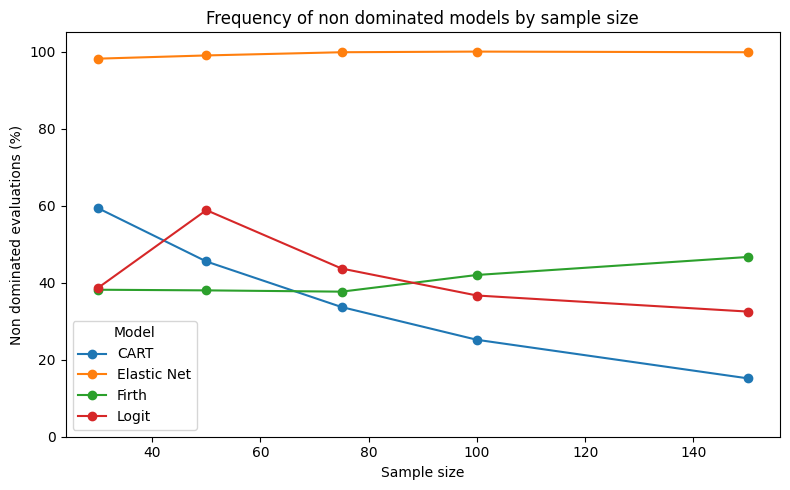

In [8]:
summary_n = (
    simulation_results
    .groupby(["n", "Modelo", "Estado"])
    .size()
    .reset_index(name="Frequency")
)

totals = (
    summary_n
    .groupby(["n", "Modelo"])["Frequency"]
    .transform("sum")
)

summary_n["Percentage"] = summary_n["Frequency"] / totals * 100

figure_data = summary_n[
    summary_n["Estado"] == "No dominado"
].copy()

figure_table = figure_data.pivot(
    index="n",
    columns="Modelo",
    values="Percentage",
)

ax = figure_table.plot(marker="o", figsize=(8, 5))
ax.set_xlabel("Sample size")
ax.set_ylabel("Non dominated evaluations (%)")
ax.set_ylim(0, 105)
ax.set_title("Frequency of non dominated models by sample size")
ax.legend(title="Model")

plt.tight_layout()
plt.savefig(
    "non_dominated_by_sample_size.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()


## 9. Comparison with AUC only selection

This complementary analysis evaluates whether selecting the model with the highest mean AUC would hide alternatives with better prediction error or stability. Only datasets with complete results for all five reliability dimensions are included.

In [9]:
data = simulation_results.copy()
data["ID_dataset"] = (
    data["Escenario"].astype(str) + "_" + data["Replica"].astype(str)
)

metrics = [
    "AUC_media",
    "AUC_DE",
    "Brier_media",
    "Brier_DE",
    "DE_prediccion",
]

evaluable = data[
    (data["Estado"] != "No evaluable")
    & data[metrics].notna().all(axis=1)
].copy()

all_ids = set(data["ID_dataset"].unique())
evaluable_ids = set(evaluable["ID_dataset"].unique())
datasets_without_complete_results = sorted(all_ids - evaluable_ids)

print("Datasets without complete results:", datasets_without_complete_results)
print("Number excluded:", len(datasets_without_complete_results))
print("Fully evaluable datasets:", len(evaluable_ids))


Datasets without complete results: ['12_41', '4_20']
Number excluded: 2
Fully evaluable datasets: 2998


In [10]:
idx_auc = evaluable.groupby("ID_dataset")["AUC_media"].idxmax()

auc_winners = evaluable.loc[
    idx_auc,
    [
        "ID_dataset",
        "Modelo",
        "AUC_media",
        "AUC_DE",
        "Brier_media",
        "Brier_DE",
        "DE_prediccion",
    ],
].copy()

auc_winners = auc_winners.rename(columns={"Modelo": "Modelo_AUC"})


def best_model_minimum(column, output_name):
    idx = evaluable.groupby("ID_dataset")[column].idxmin()

    result = evaluable.loc[
        idx,
        ["ID_dataset", "Modelo", column],
    ].copy()

    return result.rename(
        columns={
            "Modelo": output_name,
            column: f"Best_{column}",
        }
    )


comparison = (
    auc_winners
    .merge(best_model_minimum("Brier_media", "Modelo_Brier"), on="ID_dataset")
    .merge(best_model_minimum("AUC_DE", "Modelo_AUC_DE"), on="ID_dataset")
    .merge(best_model_minimum("Brier_DE", "Modelo_Brier_DE"), on="ID_dataset")
    .merge(best_model_minimum("DE_prediccion", "Modelo_prediccion"), on="ID_dataset")
)

comparison["Match_Brier"] = comparison["Modelo_AUC"] == comparison["Modelo_Brier"]
comparison["Match_AUC_SD"] = comparison["Modelo_AUC"] == comparison["Modelo_AUC_DE"]
comparison["Match_Brier_SD"] = comparison["Modelo_AUC"] == comparison["Modelo_Brier_DE"]
comparison["Match_prediction_stability"] = (
    comparison["Modelo_AUC"] == comparison["Modelo_prediccion"]
)

match_columns = [
    "Match_Brier",
    "Match_AUC_SD",
    "Match_Brier_SD",
    "Match_prediction_stability",
]

comparison["Additional_dimensions_won"] = comparison[match_columns].sum(axis=1)

print("AUC winner differs from best Brier model:",
      f"{(1 - comparison['Match_Brier'].mean()) * 100:.2f}%")
print("AUC winner differs from best AUC stability model:",
      f"{(1 - comparison['Match_AUC_SD'].mean()) * 100:.2f}%")
print("AUC winner differs from best Brier stability model:",
      f"{(1 - comparison['Match_Brier_SD'].mean()) * 100:.2f}%")
print("AUC winner differs from best prediction stability model:",
      f"{(1 - comparison['Match_prediction_stability'].mean()) * 100:.2f}%")

distribution = (
    comparison["Additional_dimensions_won"]
    .value_counts()
    .sort_index()
    .rename_axis("Additional_dimensions_won")
    .reset_index(name="Frequency")
)

distribution["Percentage"] = (
    distribution["Frequency"] / len(comparison) * 100
)

distribution


AUC winner differs from best Brier model: 42.26%
AUC winner differs from best AUC stability model: 52.80%
AUC winner differs from best Brier stability model: 47.13%
AUC winner differs from best prediction stability model: 45.50%


,Additional_dimensions_won,Frequency,Percentage
0,0,866,28.885924
1,1,436,14.543029
2,2,110,3.669113
3,3,635,21.180787
4,4,951,31.721147


In [11]:
non_dominated_counts = (
    evaluable[evaluable["Estado"] == "No dominado"]
    .groupby("ID_dataset")
    .size()
)

multiple_non_dominated = non_dominated_counts[non_dominated_counts > 1]

print(
    "Datasets with more than one non dominated model:",
    len(multiple_non_dominated),
)
print(
    "Percentage:",
    f"{len(multiple_non_dominated) / len(evaluable_ids) * 100:.2f}%",
)

auc_winner_best_nowhere = (comparison["Additional_dimensions_won"] == 0).sum()

print(
    "Datasets where the highest AUC model was not best in any "
    "of the other four dimensions:",
    auc_winner_best_nowhere,
)
print(
    "Percentage:",
    f"{auc_winner_best_nowhere / len(comparison) * 100:.2f}%",
)


Datasets with more than one non dominated model: 2047
Percentage: 68.28%
Datasets where the highest AUC model was not best in any of the other four dimensions: 866
Percentage: 28.89%


## 10. Notes on the real case study

The real participant dataset is not included in this public repository because it contains information collected from human participants. The manuscript uses the real dataset only as a methodological case study. Public materials should not contain identifiable or restricted participant data.

A separate script for the real case can be shared only if it does not expose participant level records and if its input requirements are clearly documented.